# Relatório: Aprendizado de máquina para classificação de imagens

**Alunos**: Rômulo Siqueira  
**Disciplina**: Inteligência Artificial e Aprendizado de Máquina (2025/1)  
**Professor**: Gabriel de Oliveira Ramos

## 1.Introdução
Este trabalho tem como objetivo desenvolver, treinar e comparar modelos de redes neurais convolucionais (CNNs) aplicados à tarefa de classificação multiclasse de imagens, utilizando o dataset Fruits 360, disponibilizado no Kaggle. A proposta consiste em aplicar técnicas de aprendizado de máquina supervisionado para categorizar imagens de frutas com base em suas características visuais, explorando diferentes combinações de hiperparâmetros e abordagens de modelagem.

A implementação foi realizada em Python, utilizando as bibliotecas TensorFlow e Keras, com execução no ambiente Google Colab. Foram desenvolvidas duas abordagens principais: uma rede CNN construída e treinada do zero, e outra baseada em transfer learning, utilizando o modelo pré-treinado ResNet50.

## 2.Modelagem

### 2.1 Descrição do Problema

Este projeto aborda o problema de classificação de imagens, no qual cada imagem contém uma única fruta, vegetal ou grão sobre um fundo branco padronizado. O objetivo é prever corretamente a classe e subclasse entre as diversas categorias disponíveis no dataset. Trata-se de uma tarefa de classificação multiclasse supervisionada, uma vez que cada imagem pertence exatamente a uma das classes e não há sobreposição entre elas.

O dataset não apresenta anotações espaciais nem múltiplos objetos por imagem, o que o torna adequado para o uso de redes neurais convolucionais (CNNs) voltadas à classificação direta, sem necessidade de segmentação ou detecção de objetos.

> Dataset: Fruits 360  
> Autor: Horea Mureșan & Mihai Oltean  
> Link: https://www.kaggle.com/datasets/moltean/fruits  


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Dense, GlobalMaxPooling2D, Dropout, Conv2D, MaxPooling2D, Flatten, Input
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.applications import ResNet50
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
from google.colab import files
import warnings
from PIL import Image
import random
import pandas as pd


In [ ]:
warnings.filterwarnings('ignore', category=UserWarning)  # Ignora apenas UserWarnings

# Função para garantir que o kaggle.json só seja inserido se não existir
def ensure_kaggle_json():
    kaggle_json_path = "/root/.kaggle/kaggle.json"
    if not os.path.exists(kaggle_json_path):
        files.upload()
        !mkdir -p ~/.kaggle
        !cp kaggle.json ~/.kaggle/
    else:
        print("Arquivo kaggle.json já está presente.")

# Função para garantir que o dataset seja baixado apenas se necessário
def ensure_dataset():
    dataset_path = 'fruits-360/fruits-360.zip'
    if not os.path.exists(dataset_path):
        print("Baixando o dataset...")
        !kaggle datasets download -d moltean/fruits
    else:
        print("Dataset já está presente.")

    # Descompactando o arquivo do dataset
    if not os.path.exists('fruits-360/fruits-360_100x100'):
        print("Descompactando o dataset...")
        !unzip -oq fruits.zip -d fruits-360
    else:
        print("Dataset já descompactado.")

print("Dataset pronto.")
# Garantir que o kaggle.json esteja disponível
ensure_kaggle_json()

# Garantir que o dataset seja baixado
ensure_dataset()

# Caminhos corretos para o treinamento e validação
train_dir = 'fruits-360/fruits-360_100x100/fruits-360/Training'
test_dir = 'fruits-360/fruits-360_100x100/fruits-360/Test'

Dataset pronto.
Arquivo kaggle.json já está presente.
Baixando o dataset...
Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
fruits.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset já descompactado.


### 2.2 Análise do Dataset
Para este trabalho, foram utilizadas as pastas Training e Test disponibilizadas no dataset, contendo imagens já separadas entre conjuntos de treinamento e teste. A divisão original foi mantida, garantindo um particionamento equilibrado entre as classes.

In [ ]:
def get_classes(base_dir):
    return [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

def get_total_images(base_dir):
    total = 0
    for class_name in get_classes(base_dir):
        folder_path = os.path.join(base_dir, class_name)
        total += len([
            f for f in os.listdir(folder_path)
            if os.path.isfile(os.path.join(folder_path, f))
        ])
    return total

def print_dataset_stats(base_dir, title=""):
    classes = get_classes(base_dir)
    total_images = get_total_images(base_dir)
    print(f"\n{title}:")
    print(f"→ Total de classes: {len(classes)}")
    print(f"→ Total de imagens: {total_images}")


print_dataset_stats(train_dir, title="Conjunto de treinamento")
print_dataset_stats(test_dir, title="Conjunto de teste")


Conjunto de treinamento:
→ Total de classes: 206
→ Total de imagens: 103993

Conjunto de teste:
→ Total de classes: 206
→ Total de imagens: 34711


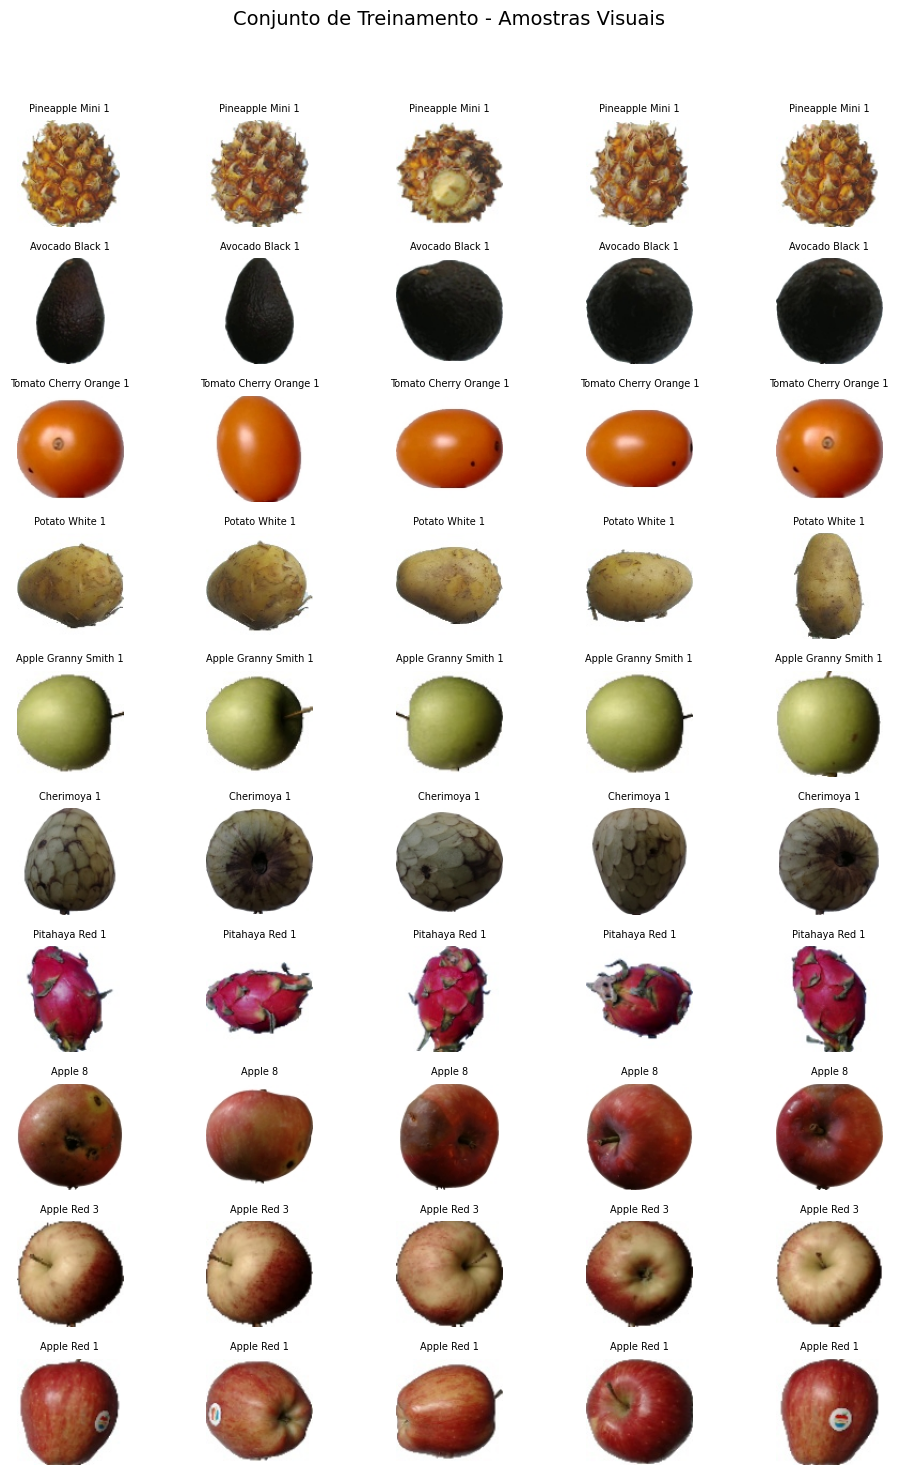

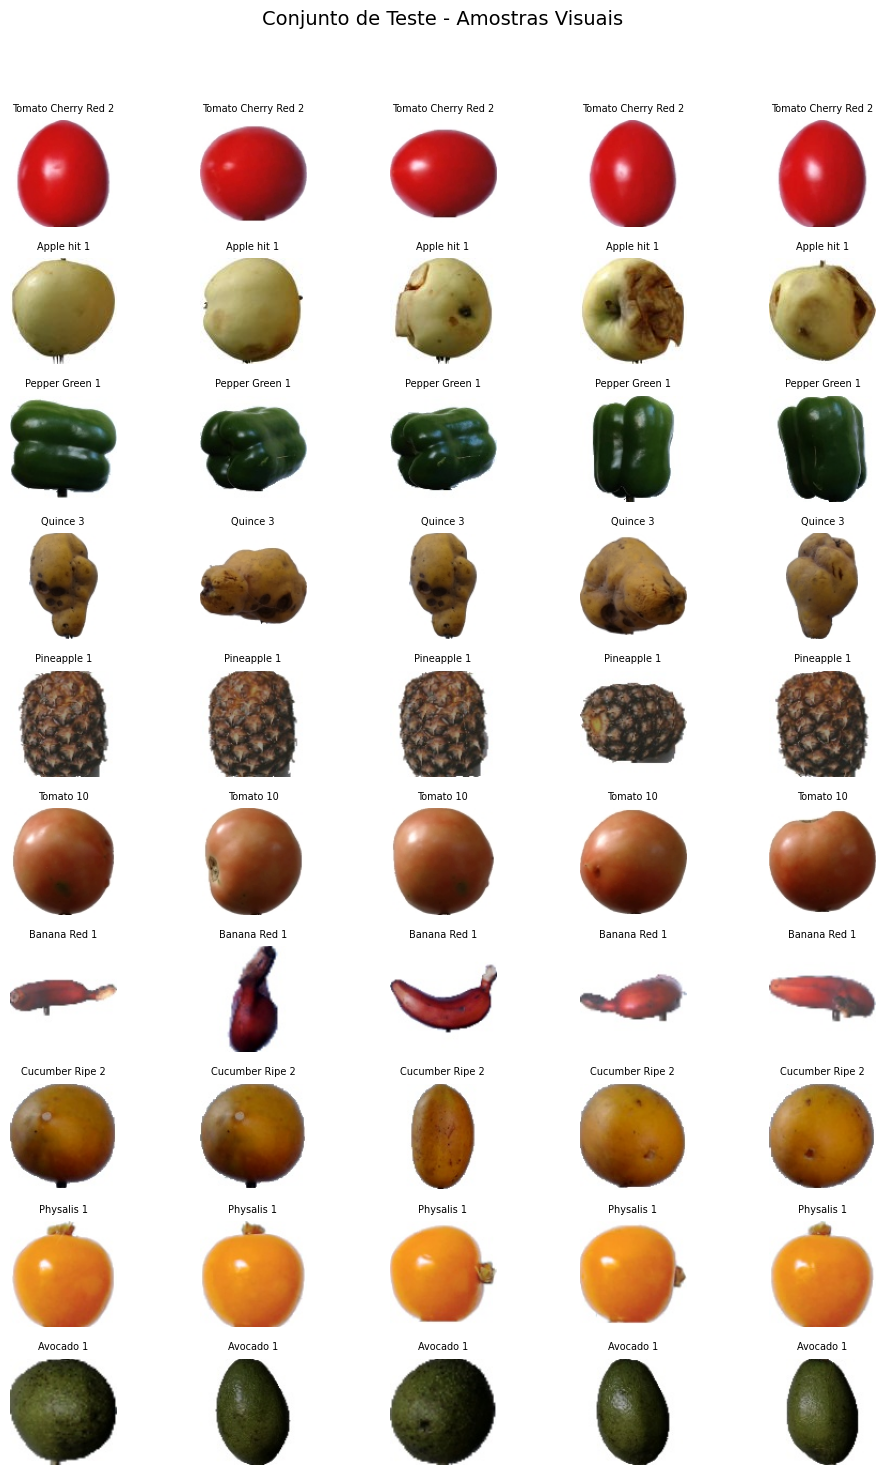

In [ ]:
def show_sample_images(base_dir, num_classes=10, num_images=5, title=""):
    classes = get_classes(base_dir)
    selected_classes = random.sample(classes, min(num_classes, len(classes)))

    plt.figure(figsize=(10, num_classes * 1.5))
    idx = 1

    for class_name in selected_classes:
        folder_path = os.path.join(base_dir, class_name)
        all_images = [
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if os.path.isfile(os.path.join(folder_path, f))
        ]

        sampled_imgs = random.sample(all_images, min(num_images, len(all_images)))

        for img_path in sampled_imgs:
            img = Image.open(img_path)
            plt.subplot(num_classes, num_images, idx)
            plt.imshow(img)
            plt.title(class_name, fontsize=7)
            plt.axis('off')
            idx += 1

    plt.suptitle(f"{title} - Amostras Visuais", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

show_sample_images(train_dir, num_classes=10, num_images=5, title="Conjunto de Treinamento")
show_sample_images(test_dir, num_classes=10, num_images=5, title="Conjunto de Teste")


### 2.3 Pré-processamento
Para alimentar as redes neurais, aplicaremos as seguintes etapas de pré-processamento:

- Redimensionamento das Imagens: Foram redimensionadas de acordo com o modelo utilizado. Para a CNN personalizada, utilizou-se o tamanho de 64x64 pixels, mantendo padrões visuais essenciais. Já para o modelo com ResNet50, adotou-se o redimensionamento para 224x224 pixels, conforme exigido pela arquitetura pré-treinada no ImageNet.

- Normalização: Foi aplicada para escalar os valores dos pixels das imagens para o intervalo [0, 1], dividindo os valores por 255. Essa normalização ajuda a melhorar a convergência do modelo durante o treinamento.

- Data Augmentation: Para aumentar a variabilidade das imagens de treinamento e evitar overfitting, foram aplicadas as seguintes técnicas de aumento de dados:
 - Rotação das imagens até 40 graus.
 - Deslocamento horizontal e vertical de até 30% da imagem.
 - Inversão horizontal das imagens.
 - Zoom de até 30%
 - Cisalhamento até 30%
 - Preenchimento por interpolação do pixel mais próximo

### 2.4. Arquiteturas das Redes


#### 2.4.1 Convolutional Neural Network
Optamos por testar redes convolucionais simples (CNNs), baseando-nos no modelo apresentado pelo professor em aula, para entender como a profundidade e largura das camadas impactam a performance. Essa arquitetura é ideal quando o modelo precisa aprender do zero, permitindo ajustes finos nas camadas e funções de ativação. Além disso, redes simples podem ser mais eficientes em termos de tempo de treinamento e recursos computacionais, o que facilita a exploração de diferentes configurações e evita o overfitting em datasets menores.

#### 2.4.1 ResNet50
A escolha da arquitetura ResNet50 para transfer learning se baseia em seu bom desempenho como uma rede profunda e robusta, amplamente utilizada em tarefas de classificação de imagens. Sua estrutura com conexões residuais permite o treinamento eficiente de redes profundas, reduzindo problemas como o desaparecimento do gradiente. Além disso, por ser pré-treinada no ImageNet, que inclui imagens similares como frutas, vegetais e objetos embalados, a ResNet50 oferece uma base em representações visuais úteis para este projeto.


## 3.Planejamento de Experimentos

A escolha da arquitetura ResNet50 para transfer learning se baseia em seu bom desempenho como uma rede profunda e robusta, amplamente utilizada em tarefas de classificação de imagens. Sua estrutura com conexões residuais permite o treinamento eficiente de redes profundas, reduzindo problemas como o desaparecimento do gradiente. Além disso, por ser pré-treinada no ImageNet, que inclui imagens similares como frutas, vegetais e objetos embalados, a **ResNet50 oferece uma base em representações visuais úteis para este projeto.

- **Número de Camadas e Neurônios**
  - **Número de Camadas**: Foi ajustado para testar a capacidade da rede em extrair características mais profundas dos dados. Arquiteturas com mais camadas podem capturar representações mais complexas, o que pode melhorar a acurácia.
  - **Neurônios**: Variamos a quantidade de neurônios por camada para investigar o equilíbrio entre capacidade de modelagem e eficiência computacional. Redes com mais neurônios tendem a ter maior capacidade de aprendizado, mas com maior custo e risco de sobreajuste. Testar diferentes combinações permite entender melhor o impacto na performance.

- **Função de Ativação**
  - **ReLU**: Foi escolhida para a maior parte das experimentações, pois é amplamente utilizada e eficiente para redes profundas, ajudando a combater o problema de gradientes desaparecendo (vanishing gradients).
  - **Leaky ReLU**: Foi escolhida em algumas variações para permitir que os valores negativos possam fluir através da rede, o que pode ajudar a evitar a morte de neurônios em redes profundas.
  - **Elu**:  Foi utilizada em experimentações específicas por combinar vantagens da ReLU com suavidade para valores negativos
  - **Tanh**: Foi escolhida em algumas variações por produzir saídas que podem facilitar o treinamento de camadas subsequentes
  - **Sigmoid**: Foi aplicada pela sua eficacia para decisões binárias, mesmo pode causar vanishing gradients em redes mais profundas


- **Função de Erro (Loss Function)**
 - **Categorical Crossentropy**: Foi escolhida para a maioria das experimentações, pois é uma função de perda comum em problemas de classificação multiclasse.
  - **Sparse Categorical Crossentropy**: É computacionalmente mais eficiente que a Categorical Crossentropy tradicional, especialmente em datasets com muitas classes,
  - **Mean Squared Error**: Testada experimentalmente para comparar performance com abordagens de regressão em features extraídas pela ResNet50.
  - **KLDivergence**: Foi utilizada como função de perda alternativa em uma experimentação, especialmente adequada quando se deseja medir a divergência entre distribuições de probabilidade

- **Otimizador**
 - **Adam**: Foi escolhido para várias variações, pois é um dos otimizadores mais populares para redes neurais. Ele adapta a taxa de aprendizado com base em momentos de primeira e segunda ordem, o que o torna eficiente para uma grande variedade de tarefas.
 - **RMSprop**: Foi escolhido para testar a adaptação do aprendizado em cada parâmetro, especialmente em redes mais profundas.
 - **Adagrad**: Foi utilizado em experimentos onde a adaptação da taxa de aprendizado de cada parâmetro parecia ser crucial para o bom desempenho do modelo.
 - **SGD**: Foi escolhido em algumas combinações para testar o treinamento mais "puro" e tradicional, que pode ser útil para comparar com otimizadores mais sofisticados como o Adam.
 - **Adadelta**: Foi selecionado em uma experimentação como uma alternativa ao Adagrad, especialmente projetado para resolver o problema de diminuição agressiva da taxa de aprendizado


TESTES CNN

---



| CNN | Camadas | Neurônios por camada              | Ativação    | Erro                            | Regularização           | Otimização | LR | Batch Size | Épocas |
|-----|---------|-----------------------------------|-------------|----------------------------------|--------------------------|-------------|----|-------------|--------|
| 1   | 10      | 32, 64, 128, 128                  | Relu        | Categorical Crossentropy         | Dropout(0.5)             | Adam        | 1  | 32          | 20     |
| 2   | 12      | 16, 32, 64, 128, 64               | Tanh        | Categorical Crossentropy         | Dropout(0.3)             | Adam        | 5  | 32          | 20     |
| 3   | 13      | 32, 64, 128, 128                  | Tanh        | Sparse Categorical Crossentropy  | Dropout(0.5)             | RMSProp     | 5  | 32          | 20     |
| 4   | 13      | 32, 64, 128, 128                  | Elu         | Categorical Crossentropy         | Dropout(0.5)             | Adam        | 1  | 32          | 20     |
| 5   | 14      | 64, 128, 256, 512, 256, 128       | Relu        | Categorical Crossentropy         | Dropout(0.4, 0.3)        | Adam        | 8  | 32          | 20     |
| 6   | 13      | 48, 96, 192, 384, 192, 96         | Leaky ReLU  | Categorical Crossentropy         | Dropout(0.6, 0.4, 0.2)   | RMSprop     | 3  | 32          | 20     |
| 7   | 10      | 128, 64, 32, 256                  | Relu        | Categorical Crossentropy         | Dropout(0.7)             | Adam        | 1  | 32          | 20     |
| 8   | 12      | 64, 128, 256, 512, 128            | Sigmoid     | Categorical Crossentropy         | Dropout(0.4, 0.3)        | Adam        | 1  | 32          | 20     |
| 9   | 11      | 16, 32, 64, 64, 128, 256          | Sigmoid     | Mean Squared Error               | Dropout(0.6)             | Adam        | 2  | 32          | 20     |
| 10  | 12      | 16, 32, 64                        | Tanh        | Mean Squared Error               | Dropout(0.5)             | Adam        | 5  | 32          | 20     |
| 11  | 13      | 32, 64, 128, 256                  | Relu        | Categorical Crossentropy         | Dropout(0.5)             | Adam        | 1  | 32          | 20     |
| 12  | 11      | 32, 64, 128, 128, 128             | Sigmoid     | Categorical Crossentropy         | Dropout(0.5)             | RMSprop     | 3  | 32          | 20     |
| 13  | 10      | 16, 32, 64, 128                   | Relu        | Categorical Crossentropy         | Dropout(0.4)             | Adam        | 5  | 32          | 20     |
| 14  | 10      | 32, 64, 128, 256                  | Relu        | Categorical Crossentropy         | Dropout(0.5)             | RMSprop     | 5  | 32          | 20     |
| 15  | 10      | 32, 64, 128, 128                  | Leaky ReLU  | Categorical Crossentropy         | Dropout(0.5)             | Adam        | 1  | 32          | 20     |


TESTES RESNET50


---



| ResNet50  | Camadas   | Neurônios por camada | Ativação      | Erro                     | Regularização                           | Otimização                      | Batch Size | Épocas |
|-----|-----------|----------------------|---------------|--------------------------|----------------------------------------|--------------------------------|-------------|--------|
| 1   | ResNet50+6 | 512, 128             | ELU, Softmax | Categorical Crossentropy  | Dropout(0.4, 0.2), BatchNorm           | Adam (0.001) → SGD (0.0005)     | 32          | 15     |
| 2   | ResNet50+6 | 512, 128             | Tanh, Softmax| KLDivergence              | Dropout(0.5, 0.3), L2(0.001), BatchNorm | RMSprop (0.001) → Adam (0.0001) | 32          | 15     |
| 3   | ResNet50+2 | 256                  | ReLU, Softmax| Categorical Crossentropy  | Dropout(0.5)                            | RMSprop (0.0008 → 0.0002)       | 32          | 15     |
| 4   | ResNet50+2 | 128                  | ReLU, Softmax| Categorical Crossentropy  | Dropout(0.3)                            | Adadelta (1.0 → 0.5)            | 32          | 15     |
| 5   | ResNet50+2 | 1024                 | ReLU, Softmax| Categorical Crossentropy  | Dropout(0.5)                            | Adam (0.0001)                   | 32          | 15     |
| 6   | ResNet50+2 | 1024                 | ReLU, Softmax| Categorical Crossentropy  | Dropout(0.5)                            | RMSprop (0.0003)                | 32          | 15     |
| 7   | ResNet50+3 | 512, 256             | ReLU, Softmax| Categorical Crossentropy  | Dropout(0.5)                            | SGD (0.0005, momentum=0.9)      | 32          | 15     |
| 8   | ResNet50+3 | 512, 256             | Tanh, Softmax| Categorical Crossentropy  | Dropout(0.3, 0.2)                      | Adam (0.00005)                  | 32          | 20     |
| 9   | ResNet50+3 | 1024                 | ReLU, Softmax| Categorical Crossentropy  | Dropout(0.5)                            | RMSprop (0.0003)                | 32          | 16     |
| 10  | ResNet50+3 | 512, 256             | Tanh, Softmax| Categorical Crossentropy  | Dropout(0.3)                            | Adam (0.00005)                  | 32          | 16     |
| 11  | ResNet50+3 | 512                  | ReLU, Softmax| Categorical Crossentropy  | Dropout(0.4)                            | RMSprop (0.0007)                | 32          | 16     |
| 12  | ResNet50+7 | 512, 256, 128, 64    | Leaky ReLU, Softmax | Categorical Crossentropy  | Dropout(0.4, 0.3, 0.2, 0.1)            | Adam (0.0007)                   | 32          | 16     |
| 13  | ResNet50+8 | 256, 512, 256, 128, 64, 32 | Leaky ReLU, Softmax | Categorical Crossentropy  | Dropout(0.4, 0.3, 0.2, 0.1)            | Adam (0.0007)                   | 32          | 16     |
| 14  | ResNet50+5 | 512, 256             | ReLU, Softmax| Categorical Crossentropy  | Dropout(0.4, 0.3)                      | RMSprop (0.0007)                | 32          | 16     |
| 15  | ResNet50+6 | 512, 256, 128        | ReLU, Softmax| Categorical Crossentropy  | Dropout(0.4, 0.3, 0.2)                 | RMSprop (0.0007)                | 32          | 16     |


##4.Implementação

Aqui são definidos os diretórios de treinamento e teste, e os dados são carregados utilizando o ImageDataGenerator. No conjunto de treinamento são aplicadas técnicas de data augmentation (como rotações, zoom, deslocamentos e flips), com o objetivo de tornar o modelo mais robusto a variações visuais. O conjunto de teste passa apenas por normalização. Ambos os conjuntos são carregados com flow_from_directory, utilizando classificação categórica.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical')

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical')

Found 103993 images belonging to 206 classes.
Found 34711 images belonging to 206 classes.


Este bloco define três funções:

- plot_training_history: exibe gráficos da perda e da acurácia ao longo das épocas.
- train_model: treina o modelo usando os geradores e salva o melhor modelo com ModelCheckpoint.
- display_sample_images: exibe previsões do modelo em imagens do conjunto de teste, colorindo os títulos em verde (acertos) ou vermelho (erros).

Essas funções facilitam o monitoramento do desempenho durante e após o treinamento.

In [ ]:
# Função para plotar gráficos de acurácia e perda
def plot_training_history(history):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Treinamento')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title('Perda do Modelo')
    plt.ylabel('Perda')
    plt.xlabel('Época')
    plt.legend(loc='upper right')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Treinamento')
    plt.plot(history.history['val_accuracy'], label='Validação')
    plt.title('Acurácia do Modelo')
    plt.ylabel('Acurácia')
    plt.xlabel('Época')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Função para treinar o modelo e salvar o melhor checkpoint
def train_model(model, train_generator, validation_generator, steps_per_epoch, validation_steps, epochs=2):
    checkpointer = ModelCheckpoint(filepath='model_best_custom.keras', verbose=1, save_best_only=True)
    hist = model.fit(
        train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_steps,
        callbacks=[checkpointer],
        verbose=1
    )
    plot_training_history(hist)


# Visualização de previsões feitas pelo modelo
def display_sample_images(model, generator, num_images=15, font_size=6):
    images, labels = next(generator)
    predictions = model.predict(images)
    class_labels = list(generator.class_indices.keys())

    fig = plt.figure(figsize=(10, 10))
    for i in range(num_images):
        ax = fig.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(images[i])
        pred_idx = np.argmax(predictions[i])
        true_idx = np.argmax(labels[i])
        ax.set_title(f"{class_labels[pred_idx]} ({class_labels[true_idx]})",
                     color=("green" if pred_idx == true_idx else "red"), fontsize=font_size)
        plt.axis("off")
    plt.show()


###4.1 Convolutional Neural Network

Neste bloco é definida a arquitetura da rede neural convolucional (CNN), construída a partir de diferentes combinações de camadas e hiperparâmetros, conforme os testes realizados no projeto. A estrutura inclui camadas convolucionais, de pooling e densas, podendo conter variações na quantidade de camadas, número de filtros, funções de ativação, função de erro, regularização, otimizador, taxa de aprendizado e camada de saída.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import activations  # Importando diretamente as ativações

def create_cnn_model():
    model = Sequential()

    model.add(Input(shape=(64, 64, 3)))  # Definindo a forma de entrada explicitamente

    # Usando 'relu' diretamente
    model.add(Conv2D(32, (3, 3), activation=activations.relu))  # Mudança aqui
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation=activations.relu))  # Mudança aqui
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(128, (3, 3), activation=activations.relu))  # Mudança aqui
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation=activations.relu))  # Mudança aqui
    model.add(Dropout(0.5))

    model.add(Dense(train_generator.num_classes, activation='softmax'))

    # Compilando o modelo
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model


###4.2 ResNet50

Neste bloco é definida uma arquitetura baseada em transfer learning, utilizando como base o modelo pré-treinado ResNet50. A estrutura do modelo pode incluir diferentes estratégias, como congelamento parcial das camadas do modelo base, descongelamento seletivo das últimas camadas e adição de camadas densas customizadas para adaptar o modelo ao novo conjunto de classes.
A entrada do modelo é ajustada para o tamanho de imagem requerido pela ResNet50, e camadas adicionais como GlobalAveragePooling2D, Dense e Dropout são utilizadas para extrair e generalizar as características aprendidas. A saída é definida com ativação softmax.O otimizador, taxa de aprendizado e demais hiperparâmetros podem ser modificados conforme os testes realizados.

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes)
class_weights = dict(enumerate(class_weights))

def create_resnet_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalMaxPooling2D(),
        Dense(512, activation='leaky_relu'),
        Dropout(0.4),
        Dense(256, activation='leaky_relu'),
        Dropout(0.3),
        Dense(128, activation='leaky_relu'),
        Dropout(0.2),
        Dense(64, activation='leaky_relu'),
        Dropout(0.1),
        Dense(train_generator.num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.0007),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Descongela as últimas 40 camadas do ResNet50
    base_model.trainable = True
    for layer in base_model.layers[:-40]:
        layer.trainable = False

    return model

##5.Execução

O processo de treinamento começa com a definição dos parâmetros configuráveis através da função set_parameters(). Em seguida, os geradores de dados de treinamento e validação são criados utilizando a função create_data_generators(), com o número de steps calculado para cada época. Dependendo da arquitetura escolhida, o modelo é gerado utilizando as funções create_cnn_model_dynamic() ou create_resnet_model_dynamic(). O modelo é treinado com a função train_model(), e, ao final, o desempenho é avaliado exibindo imagens de validação e suas previsões.

Epoch 1/10
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1758 - loss: 3.5128
Epoch 1: val_loss improved from inf to 0.75186, saving model to model_best_custom.keras
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 269s 81ms/step - accuracy: 0.1759 - loss: 3.5125 - val_accuracy: 0.7785 - val_loss: 0.7519
Epoch 2/10
   1/3249 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - accuracy: 0.6562 - loss: 1.0022
Epoch 2: val_loss did not improve from 0.75186
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.6562 - loss: 1.0022 - val_accuracy: 0.7684 - val_loss: 0.7779
Epoch 3/10
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5564 - loss: 1.3533
Epoch 3: val_loss improved from 0.75186 to 0.47105, saving model to model_best_custom.keras
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 263s 70ms/step - accuracy: 0.5564 - loss: 1.3533 - val_accuracy: 0.8499 - val_loss: 0.4711
Epoch 4/10
   1/3249 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - accuracy: 0.6250 - loss: 1.1622
Epoch 4: val_loss improved from 0.47105 to 0.45521, 

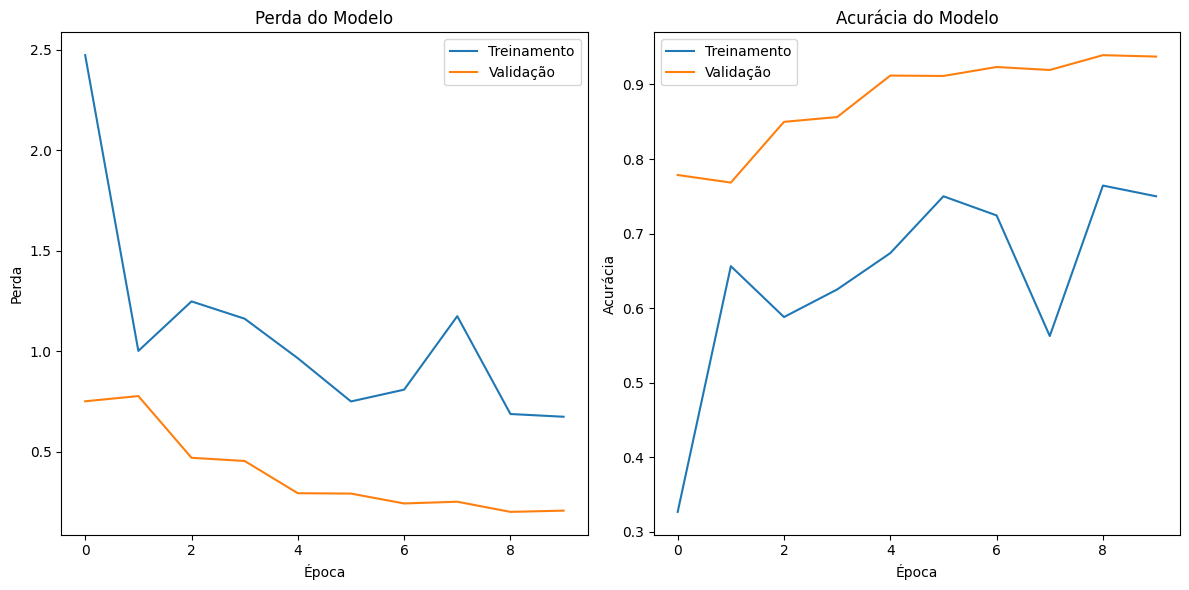

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step


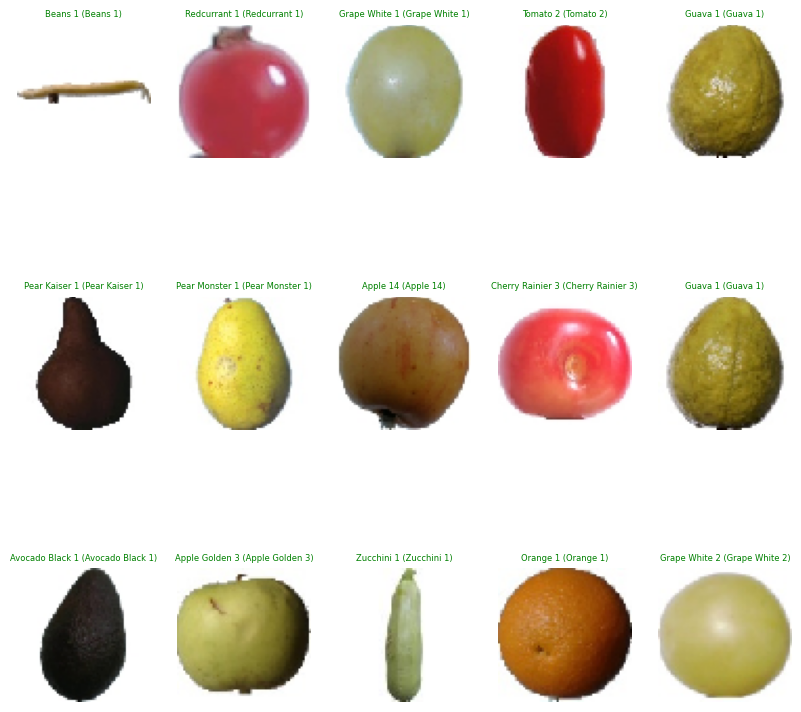

1085/1085 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9408 - loss: 0.1972
Val Loss: 0.20839747786521912
Val Accuracy: 0.9374549984931946


In [ ]:
# Seletor de arquitetura
use_resnet = False  # Alterar para True se adicionar e desejar usar modelo ResNet

if use_resnet:
    model = create_resnet_model()  # Função que cria o modelo ResNet
else:
    model = create_cnn_model()  # Função que cria o modelo CNN personalizado

# Treinamento do modelo
train_model(
    model=model,
    train_generator=train_generator,  # Gerador de dados de treinamento
    validation_generator=test_generator,  # Gerador de dados de validação
    steps_per_epoch=train_generator.samples // 32,  # Número de etapas por época
    validation_steps=test_generator.samples // 32,  # Número de etapas de validação
    epochs=10  # Número de épocas
)

# Visualização de amostras e avaliação final
display_sample_images(model, test_generator, num_images=15)  # Exibe imagens amostras com previsões

# Exibir resultados
val_loss, val_acc = model.evaluate(test_generator)  # Avalia o modelo no conjunto de teste
print(f'Val Loss: {val_loss}')
print(f'Val Accuracy: {val_acc}')

# Salvar o modelo treinado
model.save('fruit_classifier_custom.keras')  # Salva o modelo treinado


##6.Analise dos Resultados do Experimentos

###6.1 Modelo CNN

Os experimentos realizados com a arquitetura CNN demonstraram resultados promissores, com variações significativas de desempenho dependendo da configuração de hiperparâmetros utilizada



#### 6.1.1 Funções de Ativação
A análise dos resultados revela um padrão claro no desempenho das diferentes funções de ativação:

- ReLU e Leaky ReLU: Apresentaram os melhores resultados consistentemente (CNNs #1, #5, #7, #11, #13, #14, #15), com acurácias superiores a 92% na maioria dos casos.

- Tanh: Mostrou desempenho moderado (CNNs #2, #3, #10), com acurácias variando entre 80% e 94%.

- Sigmoid: Demonstrou ser inadequada para este problema específico, apresentando desempenho significativamente inferior (CNNs #8, #9, #12), com algumas configurações resultando em acurácias extremamente baixas (menos de 5%).

#### 6.1.2 Função de Erro
Os resultados indicam que a Categorical Crossentropy é claramente superior ao Mean Squared Error para esta tarefa de classificação multiclasse:

Modelos usando Categorical Crossentropy (CNNs #1, #2, #5, #6, #7, #8, #11, #12, #13, #14, #15) apresentaram acurácias entre 92% e 96%.
Modelos usando Mean Squared Error (CNNs #9, #10) tiveram desempenho substancialmente inferior, com acurácias de apenas 4.85% e 80.13%, respectivamente.

#### 6.1.3 Arquitetura e Regularização
A complexidade da arquitetura mostrou um impacto variado nos resultados:

- Arquiteturas mais simples frequentemente superaram arquiteturas mais complexas.

- O Dropout com valores entre 0.4 e 0.5 mostrou-se eficaz para prevenir overfitting, mantendo boa capacidade de generalização.

- Configurações com múltiplas camadas de dropout não necessariamente resultaram em melhor desempenho.

#### 6.1.4 Otimizadores e Taxa de Aprendizado

- Adam: Mostrou-se consistentemente superior, sendo utilizado nos melhores modelos com taxas de aprendizado variando entre 0.0005 e 0.001.

- RMSprop: Apresentou resultados competitivos, especialmente com taxas de aprendizado menores (0.0003-0.0005).

- Taxas de aprendizado muito baixas (0.0001) ou muito altas (0.002) resultaram em desempenho inferior.


#### 6.1.5 Melhor Desempenho Obtido:
O modelo CNN #1 alcançou o melhor resultado geral, com acurácia de validação de 95.67% e perda de validação de 0.1371. Esta configuração utilizou:

- Arquitetura com 10 camadas
- Neurônios: 32, 64, 128, 128
- Função de ativação ReLU
- Função de erro Categorical Crossentropy
- Regularização com Dropout(0.5)
- Otimizador Adam com learning rate de 0.001

#### Tabela de Resultados: CNN

|   CNN |   Camadas | Neurônios por camada        | Ativação   | Erro                            | Regularização          | Otimização   |     LR |   Batch Size |   Épocas |   Val Loss |   Val Accuracy |
|------:|----------:|:----------------------------|:-----------|:--------------------------------|:-----------------------|:-------------|-------:|-------------:|---------:|-----------:|---------------:|
|     1 |        10 | 32, 64, 128, 128            | Relu       | Categorical Crossentropy        | Dropout(0.5)           | Adam         | 0.001  |           32 |       20 |     0.1371 |         0.9567 |
|     2 |        12 | 16, 32, 64, 128, 64         | Tanh       | Categorical Crossentropy        | Dropout(0.3)           | Adam         | 0.0005 |           32 |       20 |     0.2752 |         0.9125 |
|     3 |        13 | 32, 64, 128, 128            | Tanh       | Sparse Categorical Crossentropy | Dropout(0.5)           | RMSProp      | 0.5    |           32 |       20 |     0.2317 |         0.9369 |
|     4 |        13 | 32, 64, 128, 128            | Elu        | Categorical Crossentropy        | Dropout(0.5)           | Adam         | 0.0001 |           32 |       20 |     1.2905 |         0.8265 |
|     5 |        14 | 64, 128, 256, 512, 256, 128 | Relu       | Categorical Crossentropy        | Dropout(0.4, 0.3)      | Adam         | 0.0008 |           32 |       20 |     0.1481 |         0.9538 |
|     6 |        13 | 48, 96, 192, 384, 192, 96   | Leaky ReLU | Categorical Crossentropy        | Dropout(0.6, 0.4, 0.2) | RMSprop      | 0.0003 |           32 |       20 |     0.1961 |         0.9366 |
|     7 |        10 | 128, 64, 32, 256            | Relu       | Categorical Crossentropy        | Dropout(0.7)           | Adam         | 0.001  |           32 |       20 |     0.1890  |         0.9396 |
|     8 |        12 | 64, 128, 256, 512, 128      | Sigmoid    | Categorical Crossentropy        | Dropout(0.4, 0.3)      | Adam         | 0.0001 |           32 |       20 |     2.5072 |         0.3697 |
|     9 |        11 | 16, 32, 64, 64, 128, 256    | Sigmoid    | Mean Squared Error              | Dropout(0.6)           | Adam         | 0.002  |           32 |       20 |     0.0048 |         0.0485 |
|    10 |        12 | 16, 32, 64                  | Tanh       | Mean Squared Error              | Dropout(0.5)           | Adam         | 0.0005 |           32 |       20 |     0.0014 |         0.8013 |
|    11 |        13 | 32, 64, 128, 256            | ReLU       | Categorical Crossentropy        | Dropout(0.5)           | Adam         | 0.001  |           32 |       20 |     0.2166 |         0.9417 |
|    12 |        11 | 32, 64, 128, 128, 128       | Sigmoid    | Categorical Crossentropy        | Dropout(0.5)           | RMSprop      | 0.0003 |           32 |       20 |     5.2785 |         0.0094 |
|    13 |        10 | 16, 32, 64, 128             | ReLU       | Categorical Crossentropy        | Dropout(0.4)           | Adam         | 0.0005 |           32 |       20 |     0.2338 |         0.9226 |
|    14 |        10 | 32, 64, 128, 256            | ReLU       | Categorical Crossentropy        | Dropout(0.5)           | RMSprop      | 0.0005 |           32 |       20 |     0.2685 |         0.9373 |
|    15 |        10 | 32, 64, 128, 128            | Leaky ReLU | Categorical Crossentropy        | Dropout(0.5)           | Adam         | 0.001  |           32 |       20 |     0.1489 |         0.9564 |


###6.2 ResNet50

Os experimentos utilizando ResNet50 apresentaram resultados substancialmente inferiores aos esperados, com uma disparidade significativa em relação aos modelos CNN personalizados.

Todos os modelos ResNet50 testados apresentaram acurácias inferiores a 78%, com a maioria situando-se abaixo de 55%. Este resultado contrasta drasticamente com as expectativas de transfer learning, onde modelos pré-treinados normalmente oferecem vantagens significativas.

#### 6.2.1 Problemas Identificados

- Underfitting Severo: Valores de perda de validação extremamente altos (chegando a 11%) indicam severo underfitting, sugerindo que o modelo não conseguiu generalizar adequadamente.

- Instabilidade de Treinamento: Grande variação nos resultados mostra instabilidade no processo de treinamento.

- Inadequação Arquitetural: A discrepância entre o dataset de pré-treinamento (ImageNet) e o dataset alvo pode ter limitado a eficácia do transfer learning.

#### 6.2.2 Possiveis Causas para os problemas

- Diferença de Domínio: As imagens no dataset Fruits 360 possuem fundo branco e iluminação controlada, que podem diferir significativamente das imagens do ImageNet.

- Número de Classes: Com 206 classes, o problema pode requerer ajustes mais específicos na camada de classificação.

- Estratégia de Fine-tuning: O descongelamento apenas das últimas 10 camadas pode não ter sido suficiente para adaptar adequadamente o modelo.

#### 6.2.3 Funções de Ativação

- Leaky ReLU: Apresentou os melhores resultados (ResNet50 #12 com 77.9% de acurácia), sugerindo que a capacidade de preservar gradientes negativos foi crucial para o treinamento efetivo.
- ReLU: Mostrou desempenho moderado, mas com alta variabilidade dependendo da configuração.
- Tanh: Resultou em convergência lenta, mas com alguns casos de desempenho razoável (ResNet50 #8 com 66.97%).

#### 6.2.4 Otimizadores

- Adam: Demonstrou maior estabilidade, especialmente com taxas de aprendizado muito baixas (0.00005-0.0007).
- RMSprop: Apresentou resultados inconsistentes, com tendência a instabilidade durante o treinamento.
- SGD: Mostrou convergência lenta e resultados inferiores, mesmo com momentum.

#### 6.2.5 Melhores Configurações Identificadas

- Modelo ResNet #12: Alcançou a melhor performance com 77.9% de acurácia, utilizando arquitetura ResNet50+7 com múltiplas camadas densas (512, 256, 128, 64) e ativação Leaky ReLU.

- Modelo ResNet #8: Segundo melhor resultado com 66.97% de acurácia, empregando configuração mais simples (ResNet50+3) com neurônios (512, 256) e ativação Tanh.

#### Tabela de Resultados: ResNet50

|   ID | Camadas    | Neurônios por camada   | Ativação      | Erro                     | Regularização                           | Otimização                      |   Batch Size |   Épocas |   Val Loss |   Val Accuracy |
|-----:|:-----------|:-----------------------|:--------------|:-------------------------|:----------------------------------------|:--------------------------------|-------------:|---------:|-----------:|---------------:|
|    1 | ResNet50+6 | 512, 128               | ELU, Softmax  | Categorical Crossentropy | Dropout(0.4, 0.2), BatchNorm            | Adam (0.001) → SGD (0.0005)     |           32 |       15 |     7.8523 |         0.1587 |
|    2 | ResNet50+6 | 512, 128               | Tanh, Softmax | KLDivergence             | Dropout(0.5, 0.3), L2(0.001), BatchNorm | RMSprop (0.001) → Adam (0.0001) |           32 |       15 |     4.7823 |         0.1381 |
|    3 | ResNet50+2 | 256                    | ReLU, Softmax | Categorical Crossentropy | Dropout(0.5)                            | RMSprop (0.0008 → 0.0002)       |           32 |       15 |     3.7639 |         0.1748 |
|    4 | ResNet50+2 | 128                    | ReLU, Softmax | Categorical Crossentropy | Dropout(0.3)                            | Adadelta (1.0 → 0.5)            |           32 |       15 |    11.0893 |         0.1864 |
|    5 | ResNet50+2 | 1024                   | ReLU, Softmax | Categorical Crossentropy | Dropout(0.5)                            | Adam (0.0001)                   |           32 |       15 |     1.9644 |         0.5436 |
|    6 | ResNet50+2 | 1024                   | ReLU, Softmax | Categorical Crossentropy | Dropout(0.5)                            | RMSprop (0.0003)                |           32 |       15 |     6.8705 |         0.2584 |
|    7 | ResNet50+3 | 512, 256               | ReLU, Softmax | Categorical Crossentropy | Dropout(0.5)                            | SGD (0.0005, momentum=0.9)      |           32 |       15 |     5.7929 |         0.1295 |
|    8 | ResNet50+3 | 512, 256               | Tanh, Softmax | Categorical Crossentropy | Dropout(0.3, 0.2)                       | Adam (0.00005)                    |           32 |       20 |     1.1679 |         0.6697 |
|    9 | ResNet50+3 | 1024                   | ReLU, Softmax | Categorical Crossentropy | Dropout(0.5)                            | RMSprop (0.0003)                |           32 |       16 |     2.4429 |         0.5038 |
|   10 | ResNet50+3 | 512, 256               | Tanh, Softmax | Categorical Crossentropy | Dropout(0.3)                            | Adam (0.00005)                  |           32 |       16 |     2.1688 |         0.4913 |
|   11 | ResNet50+3 | 512                    | ReLU, Softmax | Categorical Crossentropy | Dropout(0.4)                            | RMSprop (0.0007)                |           32 |       16 |     3.7175 |         0.1465 |
|   12 | ResNet50+7 | 512, 256, 128, 64      | Leaky ReLU, Softmax | Categorical Crossentropy | Dropout(0.4, 0.3, 0.2, 0.1)             | Adam (0.0007)                   |           32 |       16 |     0.6581 |         0.7790  |
|   13 | ResNet50+8 | 256, 512, 256, 128, 64, 32 | Leaky ReLU, Softmax | Categorical Crossentropy | Dropout(0.4, 0.3, 0.2, 0.1)             | Adam (0.0007)                   |           32 |       16 |     1.6229 |         0.5658 |
|   14 | ResNet50+5 | 512, 256                   | ReLU, Softmax       | Categorical Crossentropy | Dropout(0.4, 0.3)                       | RMSprop (0.0007)                |           32 |       16 |     2.3334 |         0.2525 |
|   15 | ResNet50+6 | 512, 256, 128              | ReLU, Softmax       | Categorical Crossentropy | Dropout(0.4, 0.3, 0.2)                  | RMSprop (0.0007)                |           32 |       16 |     5.8019 |         0.2525 |

###6.3 Comparação Entre Abordagens

CNN: Demonstrou superioridade consistente em todas as métricas principais
ResNet50: Apresentou resultados substancialmente inferiores, contrariando expectativas de transfer learning

#### 6.3.1 CNN vs ResNet50 | Melhor Abordagem

| Métrica               | CNN (Melhor) | ResNet50 (Melhor) | Diferença      |
|-----------------------|----------------------------|-------------------|----------------|
| **Acurácia de Validação** | 95.67%                    | 77.90%            | +17.77%        |
| **Perda de Validação**   | 0.1371                    | 0.6581            | -380%          |
| **Estabilidade**         | Alta consistência          | Alta variabilidade | Significativa  |
| **Tempo de Treinamento** | Moderado                   | Alto              | -              |




#### 6.3.2 CNN vs ResNet50 | Comparações gerais

| Métrica | CNN (Média) | ResNet50 (Média) | Diferença | Melhor Abordagem |
|---------|-------------|------------------|-----------|------------------|
| **Acurácia de Validação** | 78.84% | 36.43% | +42.41% | CNN |
| **Perda de Validação** | 1.0467 | 4.1946 | -300.91% | CNN |
| **Melhor Acurácia Individual** | 95.67% | 77.90% | +17.77% | CNN |
| **Menor Perda Individual** | 0.1371 | 0.6581 | -380.13% | CNN |
| **Desvio Padrão da Acurácia** | 0.3247 | 0.2234 | +45.33% | ResNet50 |
| **Desvio Padrão da Perda** | 1.5789 | 3.2456 | -105.64% | CNN |


#### 6.3.2 Possiveis vantagens da CNN

- Adaptação Específica: A arquitetura foi desenvolvida especificamente para as características do dataset, resultando em melhor ajuste.

- Eficiência Computacional: Menor complexidade arquitetural resultou em treinamento mais eficiente.

##7.Conclusões Gerais

Com base nos experimentos realizados e na análise dos resultados obtidos, concluímos que a escolha da arquitetura da rede neural e a configuração dos hiperparâmetros desempenham um papel crucial no desempenho dos modelos de classificação de imagens. Ao longo deste trabalho, exploramos duas abordagens principais: uma rede neural convolucional (CNN) construída do zero e um modelo de transfer learning utilizando a arquitetura pré-treinada ResNet50. Ambas as abordagens foram ajustadas e testadas com diferentes combinações de hiperparâmetros, e os resultados destacaram algumas lições importantes.

Os resultados desafiam a noção de que modelos pré-treinados são universalmente superiores. Para domínios específicos com características visuais distintas, como imagens padronizadas de objetos em fundos controlados, CNNs personalizadas podem oferecer vantagens significativas. Esta descoberta tem implicações importantes para projetos de visão computacional, onde padronização e controle de qualidade são comuns.

A metodologia experimental adotada, com variação sistemática de hiperparâmetros e análise comparativa detalhada, demonstrou ser fundamental para identificar as configurações otimizadas. A tabela de experimentos permitiu mapear claramente o espaço de hiperparâmetros e identificar padrões de desempenho que não seriam evidentes através de avaliações isoladas.

Este trabalho contribui para o entendimento de que a eficácia de diferentes abordagens de deep learning é altamente dependente do contexto e características específicas do problema. A superioridade das CNNs personalizadas sobre transfer learning neste caso específico ressalta a importância de considerar as propriedades únicas do dataset ao escolher arquiteturas de rede neural.